# Ejercicio 1 teórico para entregar
(Es un ejercicio teórico y además puede dar lugar a múltiples preguntas durante la realización de la entrevista final)

1. Busque información en internet y explique por qué a este proceso de multiplicar por un coseno de frecuencia más alta que el ancho de banda de la señal se denomina modulación en amplitud. Para visualizar este proceso, le recomendamos visualizarlo en el eje del tiempo realizando un ejemplo en Python que module un coseno de baja frecuencia por uno de frecuencia mucho mayor. Por ejemplo, tome un coseno de 100 Hz y multiplíquelo por un coseno de frecuencia 5 kHz ambas muestreadas a 40 kHz. Observe cómo se visualizan dos o tres períodos de la la señal modulada en el tiempo.




# Respuesta del Teorico

En el proceso de modulación en amplitud participan dos señales: la de información 𝑚(𝑡), señal de banda base, una banda de baja frecuencia que tendrá la información; y la portadora, la cual puede ser manipulada de acuerdo con los requerimientos de la aplicación. Además, la portadora es usada para evitar la pérdida de información que puede darse en el medio por el cual se transmite. Asimismo, por convención y practicidad se trabajará con una señal de tipo senoidal para generar la forma de onda de la señal portadora. Dicha señal se encuentra representada por la ecuación de una funcion cosenoidal para la portadora c(t)=𝐴𝑐 cos(2Pi 𝑓𝑐 t)
siendo 𝐴𝑐 y 𝑓𝑐, la amplitud de la portadora y la frecuencia de la portadora, respectivamente.

Teniendo definidas ambas señales, la modulación de amplitud se puede definir como “el proceso en el que la amplitud de la onda portadora 𝑐(𝑡) se varía en torno a valor medio, linealmente con la señal de la banda base 𝑚(𝑡)”

La frecuencia de la portadora ha de ser mayor porque eso permite su transmicion de forma mas eficiente, y además la diferencia de la señal base
Ademas mientras mayor sea la relacion fc/f0 siendo f0 la frecnuencia de la señal base, mas juntos van a estar sus frecuencias en un plot_frec(𝑚(𝑡)*c(t))


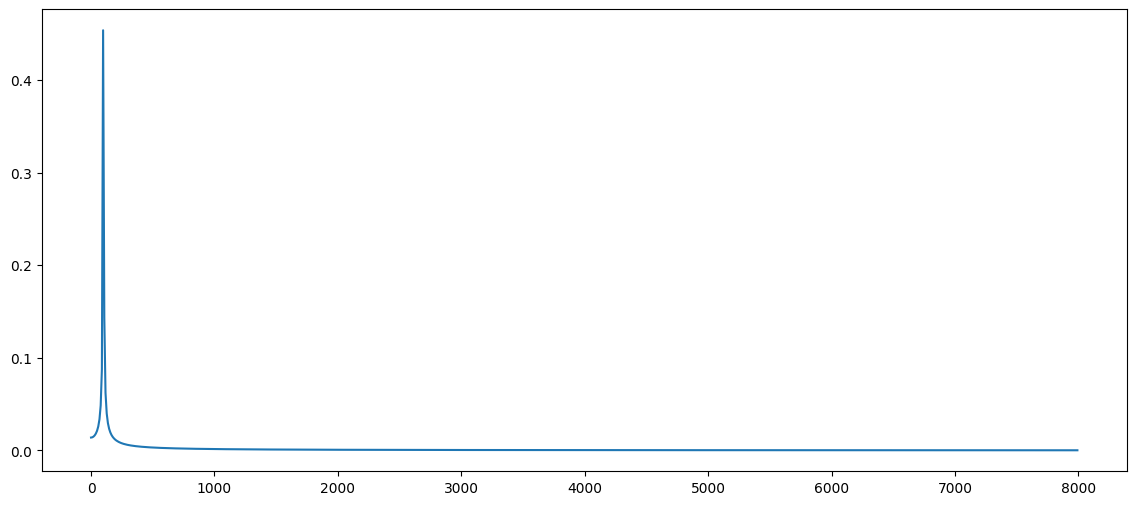

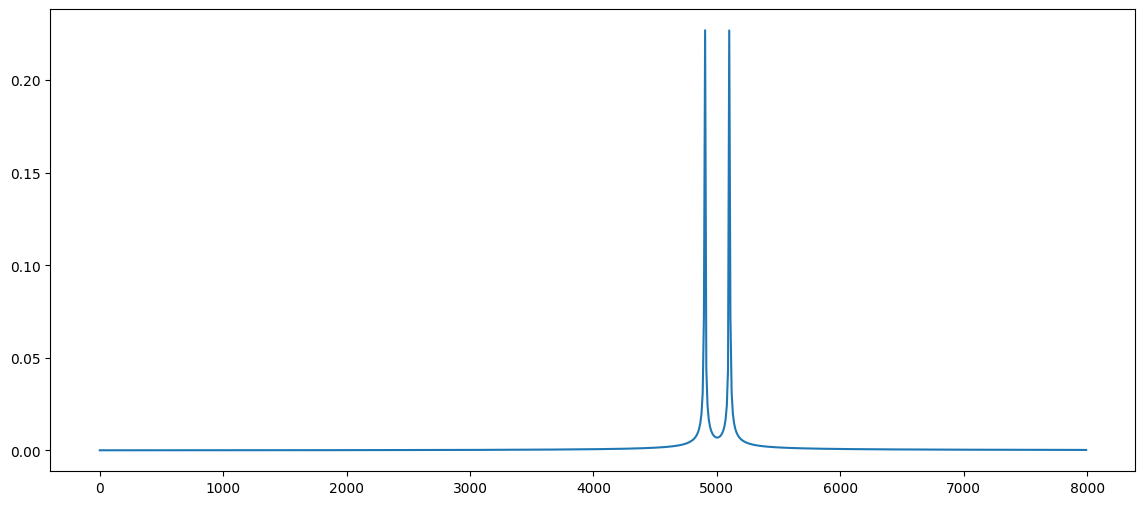

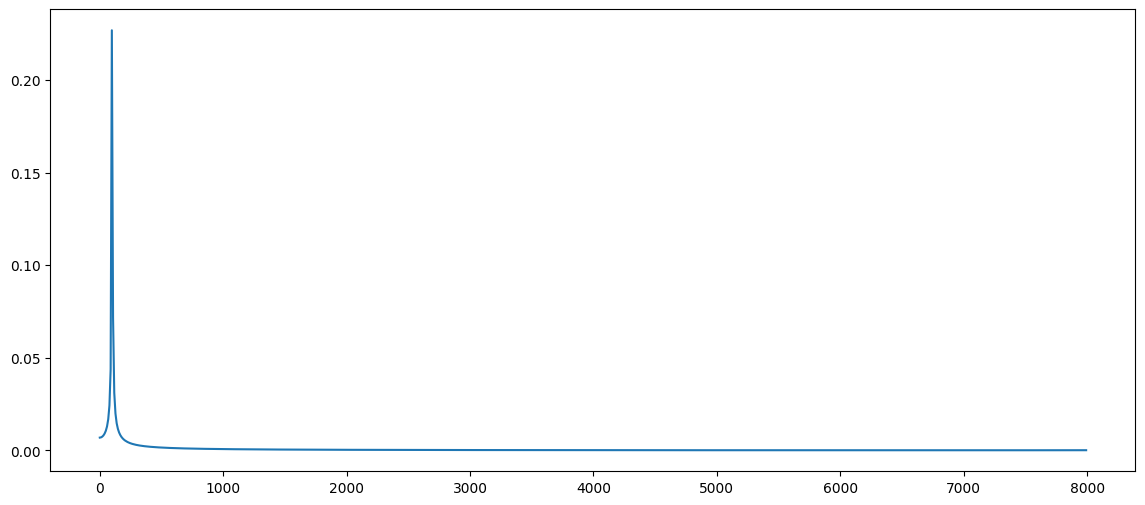

In [7]:
import numpy as np 
import matplotlib.pyplot as plt

#Frecuencia de una señal
def plot_frec(x,fs,fmax,m): 
    # esta función permite graficar las frecuencias de una señal x muestreada a tasa fs, 
    # el rango que grafica va hasta fmax, y m la  cantidad de puntos que toma para calcular la FFT .
    puntos = int(fmax/fs*m)  
    lx = len(x)
    nt = (lx + m - 1)//m
    xp = np.append(x,np.zeros(-lx+nt*m))
    xmw = np.reshape( xp, (m,nt), order='F')
    xmf = np.fft.fft(xmw,len(xmw),axis=0)/m
    xf = np.linspace(0, int(fs/2.0), int(m/2))
    plt.figure(figsize=(14,6))
    plt.plot(xf[0:puntos],np.abs(xmf[0:int(m/2),0:int(lx/m-1)]).mean(1)[0:puntos])
    plt.show()

f0=100
fs=40000
T=np.arange(0,1,1/fs)
Signal = np.cos(2*np.pi*f0*T)
Portadora = np.cos(2*np.pi*5000*T)
Y= Signal * Portadora

plot_frec(Signal,fs,8000,4096)
plot_frec(Y,fs,8000,4096)

# codigo para ver las frecuencias al multiplicar por coseno a la portadora
Base = Y*Portadora
plot_frec(Base,fs,8000,4096)


# Ejercicio 1 teórico para entregar
2. Realice un diagrama de bloques de cómo funcionaría el transmisor de Radio Nacional de España RNE (centrada en 657 kHz en Madrid y con un ancho de 10 kHz). Debajo se incluyen bloques típicos de sistemas de comunicaciones que le pueden ser de utilidad.

![diagrama_AM.png](https://iie.fing.edu.uy/~gbelcredi/tallerine/diagrama_AM.png)

![bloques.png](https://iie.fing.edu.uy/~gbelcredi/tallerine/bloques.png)


Primero se usa filtro pasa-banda para limpiar el ruido al hablar aunque se supongo que se usen tecnicas para mejorar la calidad de audio unido a un amplificador, paralelamente un oscilador, para crear la portadora, luego se mezcla para crear una señal modulada, y se pasa al oscilador(supongo que para enviar la señal, no se si oscilador es para enviar la señal, o crear la frecuencia) luego al recibir la frecuencia, se mezcla otra vezz con la portadora y se filtra Pasaba-bajos, 